In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('project_data/full_dataset.csv')

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_11012/3864665399.py:1: DtypeWarning: Columns (27,28,29,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('project_data/full_dataset.csv')


In [4]:
data.columns

Index(['tweet_id', 'user_id', 'created_at', 'ANEW_Valence', 'ANEW_Dominance',
       'ANEW_Arousal', 'Happiness', 'NRC_anger', 'NRC_anticipation',
       'NRC_disgust', 'NRC_fear', 'NRC_joy', 'NRC_sadness', 'NRC_surprise',
       'NRC_trust', 'NRC_negative', 'NRC_positive', 'Afinn_Valence',
       'OpinionFinder', 'VADER', 'male', 'female', '19-29', '30-39', '<=18',
       '>=40', 'botscore', 'time_indication', 'diag_start_interval',
       'diag_end_interval', 'diagnosis', 'non-org', 'is-org',
       'group_depression', 'group_anxiety', 'comorbid', 'cohort',
       'day_of_week', 'female_prop', 'gender', 'VADER_NEG', 'VADER_NEU',
       'VADER_POS'],
      dtype='object')

In [5]:
OUTCOME_VAR = 'VADER_NEG'

In [6]:
data_aggregated_level = data.groupby('user_id').agg({OUTCOME_VAR : 'mean', 'group_depression' : 'first', 'group_anxiety' : 'first'})[[OUTCOME_VAR, 'group_depression', 'group_anxiety']].reset_index().rename({OUTCOME_VAR : 'mean'}, axis=1)
data_aggregated_spread = data.groupby('user_id').std(numeric_only=True)[OUTCOME_VAR].reset_index().rename({OUTCOME_VAR : 'std'}, axis=1)

In [7]:
data = pd.merge(
    data_aggregated_level,
    data_aggregated_spread,
    how='inner',
    on='user_id'
)

In [8]:
data

,user_id,mean,group_depression,group_anxiety,std
0,uANX001,0.153344,False,True,0.168119
1,uANX005,0.100792,False,True,0.181874
2,uANX006,0.142498,False,True,0.202699
3,uANX007,0.058839,False,True,0.111195
4,uANX008,0.081162,False,True,0.120004
...,...,...,...,...,...
1790,uSAD000,0.059144,True,False,0.103390
1791,uSAD001,0.099302,True,False,0.151009
1792,uSAD002,0.080068,True,False,0.129869
1793,uSAD004,0.107245,True,False,0.133134


In [9]:
depression_patients = data[data['group_depression'].fillna(False)]
anxiety_patients = data[data['group_anxiety'].fillna(False)]

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_11012/3523971668.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  depression_patients = data[data['group_depression'].fillna(False)]
/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_11012/3523971668.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  anxiety_patients = data[data['group_anxiety'].fillna(False)]


In [10]:
pairs = []

for idx, row in depression_patients.iterrows():
    best_fit = anxiety_patients.loc[(anxiety_patients['mean'] - row['mean']).abs() == (anxiety_patients['mean'] - row['mean']).abs().min()]
    pairs.append({
        'depression_id' : row['user_id'],
        'anxiety_id' : best_fit['user_id'].values[0],
        'depression_mean' : row['mean'],
        'anxiety_mean' : best_fit['mean'].values[0],
        'depression_std' : row['std'],
        'anxiety_std' : best_fit['std'].values[0],
    })

In [11]:
df = pd.DataFrame(pairs)
df['mean_diff'] = (df['anxiety_mean'] - df['depression_mean']).abs()

df_best = df.loc[df['mean_diff'] < df['mean_diff'].quantile(0.8)]

df_best

,depression_id,anxiety_id,depression_mean,anxiety_mean,depression_std,anxiety_std,mean_diff
0,uDEP000,uGAD157,0.119810,0.120000,0.164220,0.158793,0.000190
1,uDEP001,uANX014,0.103927,0.104012,0.151955,0.138828,0.000085
2,uDEP002,uANX520,0.075822,0.075812,0.126651,0.121973,0.000010
3,uDEP004,uOCD089,0.072969,0.073052,0.130705,0.102925,0.000083
4,uDEP005,uOCD054,0.079587,0.079483,0.134907,0.119748,0.000104
...,...,...,...,...,...,...,...
805,uSAD000,uOCD078,0.059144,0.059116,0.103390,0.098694,0.000029
806,uSAD001,uOCD168,0.099302,0.099176,0.151009,0.152170,0.000125
807,uSAD002,uANX677,0.080068,0.080046,0.129869,0.142626,0.000021
808,uSAD004,uOCD124,0.107245,0.107192,0.133134,0.143924,0.000053


In [12]:
# Motivate this more

In [28]:
from scipy import stats  

df_ = df_best.dropna()

stats.ttest_rel(
    df_['depression_std'],
    df_['anxiety_std'])

TtestResult(statistic=np.float64(4.8571409062440996), pvalue=np.float64(1.495295000332657e-06), df=np.int64(647))

In [14]:
df_.mean(numeric_only=True)

depression_mean    0.084883
anxiety_mean       0.084881
depression_std     0.134322
anxiety_std        0.130531
mean_diff          0.000061
dtype: float64

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_11012/3834368972.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax[0].boxplot(
/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_11012/3834368972.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax[1].boxplot(


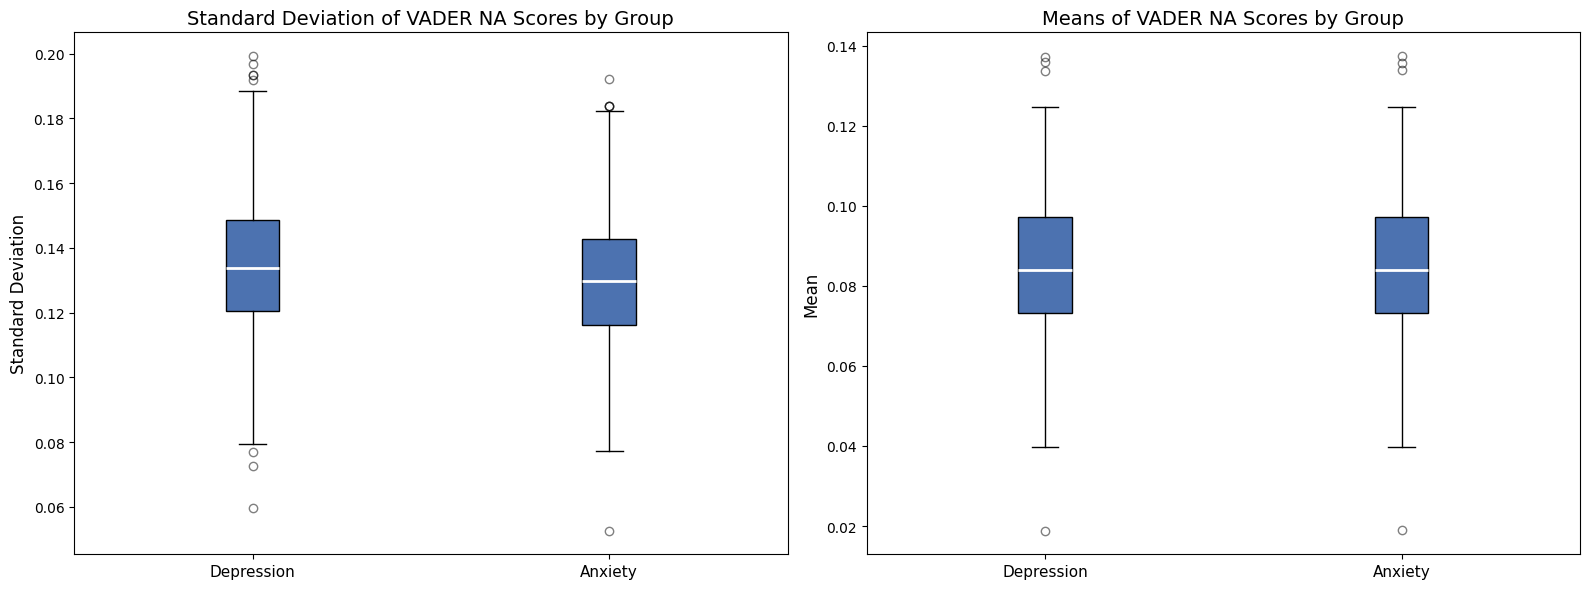

In [ ]:
import matplotlib.pyplot as plt

# Prepare data
data = [df_['depression_std'].dropna(), df_['anxiety_std'].dropna()]
labels = ['Depression', 'Anxiety']

# Set figure style
#plt.style.use('seaborn-vignette')  # or try 'ggplot', 'seaborn-whitegrid', etc.
fig, ax = plt.subplots(1,2,figsize=(16, 6))

# Create the boxplot
box = ax[0].boxplot(
    data,
    labels=labels,
    patch_artist=True,         # enable fill color
    boxprops=dict(facecolor='#4C72B0', color='black'),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', color='black', alpha=0.5)
)

# Aesthetics
ax[0].set_title('Standard Deviation of VADER NA Scores by Group', fontsize=14)
ax[0].set_ylabel('Standard Deviation', fontsize=12)
#ax.grid(True, linestyle='--', alpha=0.6)
ax[0].tick_params(axis='x', labelsize=11)
ax[0].tick_params(axis='y', labelsize=10)


data = [df_['depression_mean'].dropna(), df_['anxiety_mean'].dropna()]
labels = ['Depression', 'Anxiety']

# Set figure style
#plt.style.use('seaborn-vignette')  # or try 'ggplot', 'seaborn-whitegrid', etc.

# Create the boxplot
box = ax[1].boxplot(
    data,
    labels=labels,
    patch_artist=True,         # enable fill color
    boxprops=dict(facecolor='#4C72B0', color='black'),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', color='black', alpha=0.5)
)

# Aesthetics
ax[1].set_title('Means of VADER NA Scores by Group', fontsize=14)
ax[1].set_ylabel('Mean', fontsize=12)
#ax.grid(True, linestyle='--', alpha=0.6)
ax[1].tick_params(axis='x', labelsize=11)
ax[1].tick_params(axis='y', labelsize=10)
plt.tight_layout()

# Show the plot
plt.savefig('figures/boxplot_depression_anxiety.png', dpi=400, bbox_inches='tight')
